In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ipythonx/mvtec-ad/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/readme.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/license.txt
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/datasets/ipythonx/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/in

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

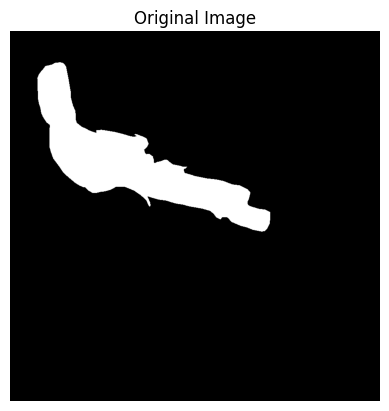

In [4]:
image_path = "/kaggle/input/datasets/ipythonx/mvtec-ad/bottle/ground_truth/contamination/017_mask.png"  

img = cv2.imread(image_path)

if img is None:
    raise ValueError("Image not found!")

# Convert to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

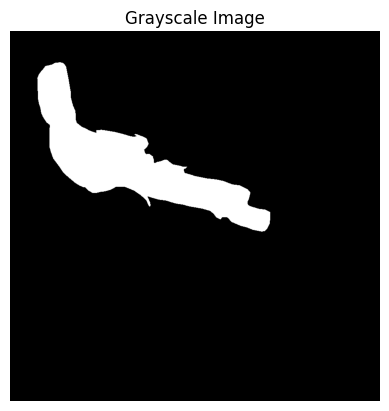

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

In [6]:
def harris_detect(gray, block_size=2, ksize=3, k=0.04, threshold=0.01):
    """
    Harris Corner Detection

    Args:
        gray: grayscale image
        block_size: neighborhood size
        ksize: kernel size
        k: Harris detector free parameter
        threshold: threshold for detecting strong corners

    Returns:
        corners_img: image with corners marked
        response: raw Harris response
    """

    gray = np.float32(gray)

    # Harris response
    response = cv2.cornerHarris(gray, block_size, ksize, k)

    # Dilate for better visualization
    response = cv2.dilate(response, None)

    # Copy image for visualization
    corners_img = cv2.cvtColor(gray.astype(np.uint8), cv2.COLOR_GRAY2BGR)

    # Mark corners
    corners_img[response > threshold * response.max()] = [0, 0, 255]

    return corners_img, response

In [7]:
harris_img, response = harris_detect(gray)


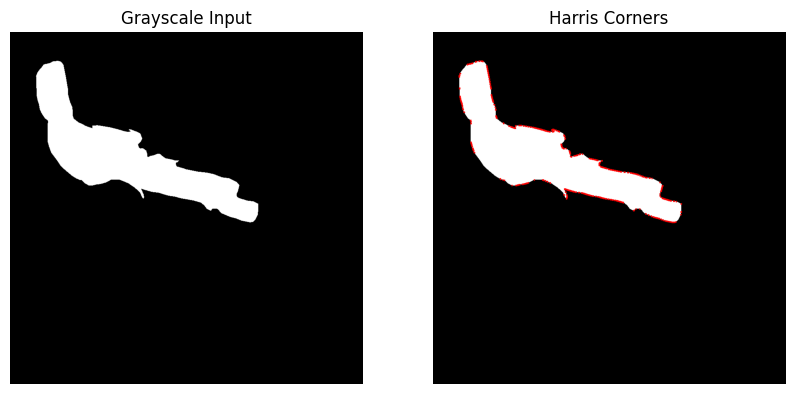

In [8]:
# Visualize Harris corners
harris_rgb = cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Grayscale Input")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Harris Corners")
plt.imshow(harris_rgb)
plt.axis("off")

plt.show()

In [11]:
def analyze_threshold_tuning(gray):
    thresholds = [0.001, 0.01, 0.05, 0.1, 0.2]
    results = []

    for t in thresholds:
        corners_img, response = harris_detect(gray, threshold=t)
        count = np.sum(response > t * response.max())
        results.append((t, count))
        print(f"threshold={t}: {count} corners")

    return results

In [15]:
print("\n--- Threshold Tuning Analysis ---")
processed_img = cv2.cvtColor(harris_img, cv2.COLOR_BGR2GRAY)
threshold_results = analyze_threshold_tuning(processed_img)


--- Threshold Tuning Analysis ---
threshold=0.001: 7307 corners
threshold=0.01: 5957 corners
threshold=0.05: 3353 corners
threshold=0.1: 2606 corners
threshold=0.2: 1150 corners


In [16]:
def plot_threshold_results(results):
    thresholds = [r[0] for r in results]
    counts = [r[1] for r in results]

    plt.figure(figsize=(6,4))
    plt.plot(thresholds, counts, marker='o')
    plt.title("Harris Threshold Tuning")
    plt.xlabel("Threshold")
    plt.ylabel("Number of Corners")
    plt.grid()
    plt.show()

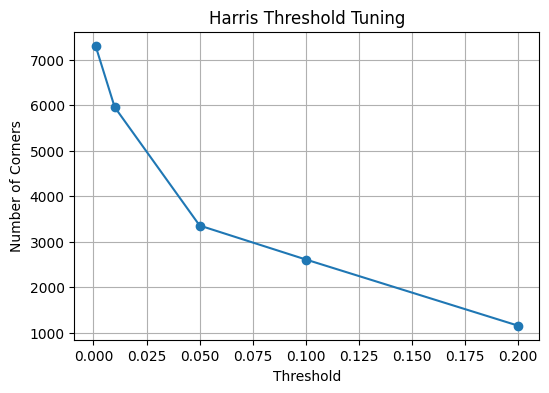

In [17]:
plot_threshold_results(threshold_results)